# 01 · Data acquisition & quality

**Question.** Can we trust the energy data enough to benchmark stores, audit bills and size savings, and which records must be excluded?

**Data.**
* **D1** NYC Local Law 84 annual energy & water disclosure: retail property types, calendar years 2019–2024 (four releases, harmonised).
* **D2** NYC LL84 monthly electricity & gas: the "utility bill" series for the same properties.
* **D3** Open-Meteo daily temperature for New York City.
* **D4** Real EMS/BMS sub-meter + PV dataset (Dryad, 2025); checked here, analysed in notebook 05.
* **D5** Emission factors & prices in `config/assumptions.yaml` (every value cited).

**Method.** A rule-based data-quality framework (`wattwise.quality`). Each rule raises a flag, flags become a 0–100 score per property, and exclusion-grade rules are applied in a fixed order so the waterfall shows exactly how many rows each rule removes.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from wattwise import io, quality as q, kpis, viz
from wattwise.weather import monthly_degree_days

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(io.assumptions()["seed"])
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
viz.use_style()

## 1 · What was downloaded
`python scripts/download_data.py` pulls only retail property types from the NYC Open Data API, plus the monthly series for the same property IDs and daily NYC weather.

In [2]:
annual_raw = io.load_annual_raw()
monthly_raw = io.load_monthly_raw()
weather_daily = io.load_weather_daily()
d4_present = (io.RAW / "d4_ems" / "reduced_data.zip").exists()

inventory = pd.DataFrame(
    [
        ["D1 LL84 annual disclosure (retail)", len(annual_raw), f"{annual_raw.year.min()}–{annual_raw.year.max()}", annual_raw.property_id.nunique()],
        ["D2 LL84 monthly electricity & gas", len(monthly_raw), f"{monthly_raw.month.min():%Y-%m} to {monthly_raw.month.max():%Y-%m}", monthly_raw.property_id.nunique()],
        ["D3 Open-Meteo daily temperature, NYC", len(weather_daily), f"{weather_daily.date.min():%Y-%m-%d} to {weather_daily.date.max():%Y-%m-%d}", 1],
        ["D4 EMS/BMS sub-meter + PV (Dryad)", np.nan, "2018–2023", 1 if d4_present else 0],
    ],
    columns=["dataset", "rows", "period", "properties / sites"],
)
inventory["rows"] = inventory["rows"].astype("Int64")
inventory

,dataset,rows,period,properties / sites
0,D1 LL84 annual disclosure (retail),3428,2019–2024,1166
1,D2 LL84 monthly electricity & gas,42264,2018-01 to 2024-12,1144
2,"D3 Open-Meteo daily temperature, NYC",3195,2018-01-01 to 2026-09-30,1
3,D4 EMS/BMS sub-meter + PV (Dryad),<NA>,2018–2023,0


In [3]:
years_monthly = sorted(int(y) for y in monthly_raw.year.unique())
missing_monthly_years = [y for y in range(min(years_monthly), max(years_monthly) + 1) if y not in years_monthly]
print("Annual calendar years found:", sorted(annual_raw.year.dropna().unique().tolist()))
print("Monthly calendar years found:", years_monthly)
print("Monthly years NOT published:", missing_monthly_years)
print("Latest monthly data point:", f"{monthly_raw.month.max():%B %Y}")

Annual calendar years found: [2019, 2020, 2021, 2022, 2023, 2024]
Monthly calendar years found: [2018, 2019, 2020, 2021, 2023, 2024]
Monthly years NOT published: [2022]
Latest monthly data point: December 2024


**Data surprise:** the monthly release skips calendar year 2022 entirely, and the most recent disclosed year is 2024 (reported in 2025). Calendar 2025 has not been published yet. Weather runs to the last complete month, so 2025 can be used as a genuine out-of-sample *forecast* year later on.

In [4]:
cohort_size = (
    annual_raw.groupby(["year", "property_type"]).property_id.nunique().unstack().fillna(0).astype(int)
)
cohort_size["Big-box cohort (Retail Store + Wholesale Club)"] = cohort_size[io.BIG_BOX_TYPES].sum(axis=1)
cohort_size

property_type,Enclosed Mall,Retail Store,Strip Mall,Supermarket/Grocery Store,Wholesale Club/Supercenter,Big-box cohort (Retail Store + Wholesale Club)
year,,,,,,
2019,14,306,65,66,12,318
2020,21,308,78,77,12,320
2021,29,297,91,99,11,308
2022,28,304,99,104,16,320
2023,33,300,131,97,21,321
2024,42,408,178,122,23,431


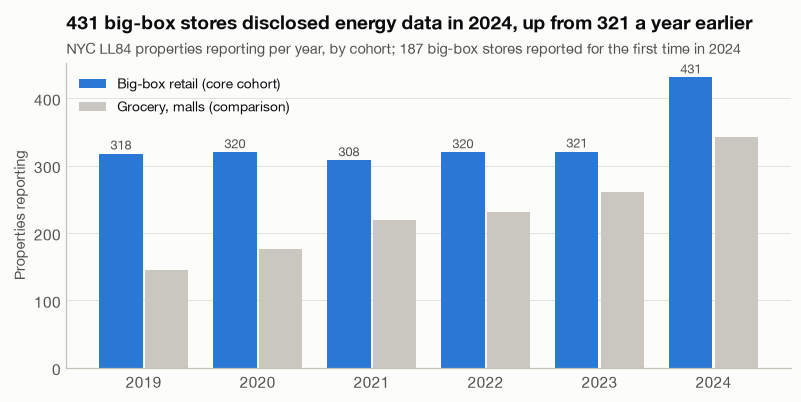

In [5]:
bbx = annual_raw[annual_raw.cohort == "Big-box retail"]
first_year = bbx.groupby("property_id").year.min()
new_latest = int((first_year == bbx.year.max()).sum())
fig, ax = plt.subplots(figsize=(8.5, 3.6))
bb = cohort_size[io.BIG_BOX_TYPES].sum(axis=1)
cmp_ = cohort_size[io.COMPARISON_TYPES].sum(axis=1)
x = np.arange(len(bb))
ax.bar(x - 0.2, bb, width=0.38, color=viz.BLUE, label="Big-box retail (core cohort)")
ax.bar(x + 0.2, cmp_, width=0.38, color=viz.CONTEXT, label="Grocery, malls (comparison)")
for i, v in enumerate(bb):
    ax.text(i - 0.2, v + 6, f"{v}", ha="center", fontsize=8.5, color=viz.INK_2)
ax.set_xticks(x, bb.index)
ax.set_ylabel("Properties reporting")
ax.legend(loc="upper left")
viz.title(ax, f"{bb.iloc[-1]} big-box stores disclosed energy data in {bb.index[-1]}, up from {bb.iloc[-2]} a year earlier",
          f"NYC LL84 properties reporting per year, by cohort; {new_latest} big-box stores reported for the first time in {bbx.year.max()}")
viz.save(fig, "01_cohort_size")
plt.show()

## 2 · Data-quality rules

| Rule | Level | Why it matters |
|---|---|---|
| Duplicate property-year | annual | double counting |
| Missing / zero floor area | annual | EUI undefined |
| No energy reported | annual | nothing to benchmark |
| Unit / scale error | annual | EUI ≈1,000× too high but plausible ÷1,000, or GFA < 1,000 ft² on an LL84-covered building |
| EUI outside 5–1,000 kBtu/ft² | annual | physically implausible for retail |
| Missing months | monthly | incomplete bills, only in years the city published |
| Zero-consumption months | monthly | meter outage or missing read |
| Flatline ≥ 3 identical months | monthly | estimated bills |
| Spike > 3× rolling median | monthly | billing catch-up / one-off |
| Monthly ≠ annual total (>10%) | both | the two city releases disagree |

In [6]:
flagged = q.merge_flags(q.annual_flags(annual_raw), q.monthly_flags(monthly_raw, "elec_kwh"))
rules = [c for c in q.RULE_LABELS if c in flagged]
hit_rates = pd.DataFrame(
    {
        "rule": [q.RULE_LABELS[c] for c in rules],
        "rows flagged": [int(flagged[c].sum()) for c in rules],
        "% of rows": [flagged[c].mean() * 100 for c in rules],
        "exclusion-grade?": ["yes" if c in q.EXCLUSION_ORDER else "no (score only)" for c in rules],
    }
)
hit_rates

,rule,rows flagged,% of rows,exclusion-grade?
0,Duplicate property-year,37,1.08,yes
1,Missing / zero floor area,0,0.00,yes
2,No energy reported,327,9.54,yes
3,"Unit / scale error (≈1,000× off)",30,0.88,yes
4,"EUI outside 5–1,000 kBtu/ft²",94,2.74,yes
5,Missing months,428,12.49,no (score only)
6,Zero-consumption months,41,1.20,no (score only)
7,Flatline (≥3 identical months),8,0.23,no (score only)
8,Spike (>3× rolling median),31,0.90,no (score only)
9,Monthly ≠ annual total (>10%),24,0.70,no (score only)


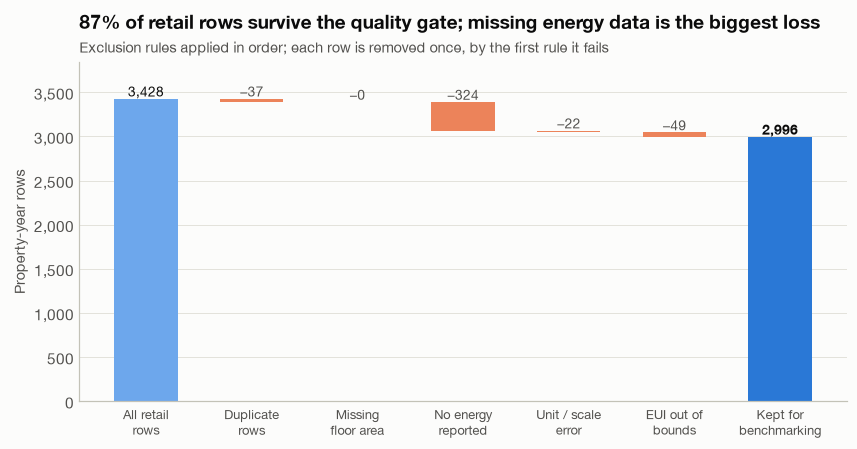

In [7]:
wf = q.exclusion_waterfall(flagged)
fig, ax = plt.subplots(figsize=(9, 4))
start = wf.rows_remaining.iloc[0]
short = {"Duplicate property-year": "Duplicate\nrows", "Missing / zero floor area": "Missing\nfloor area",
         "No energy reported": "No energy\nreported", "Unit / scale error (≈1,000× off)": "Unit / scale\nerror",
         "EUI outside 5–1,000 kBtu/ft²": "EUI out of\nbounds"}
labels = ["All retail\nrows"] + [short[s] for s in wf.step.iloc[1:]] + ["Kept for\nbenchmarking"]
level = start
ax.bar(0, start, color=viz.BLUE_RAMP[2], width=0.6)
ax.text(0, start + 25, f"{start:,}", ha="center", fontsize=9)
for i, r in enumerate(wf.iloc[1:].itertuples(), start=1):
    ax.bar(i, r.rows_removed, bottom=level - r.rows_removed, color=viz.SERIOUS if r.rows_removed else viz.CONTEXT, width=0.6)
    ax.text(i, level + 25, f"−{r.rows_removed:,}", ha="center", fontsize=9, color=viz.INK_2)
    level -= r.rows_removed
ax.bar(len(wf), level, color=viz.BLUE, width=0.6)
ax.text(len(wf), level + 25, f"{level:,}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(range(len(labels)), labels, fontsize=8.5)
ax.set_ylabel("Property-year rows")
viz.fmt_thousands(ax)
ax.set_ylim(0, start * 1.12)
kept_share = level / start
viz.title(ax, f"{kept_share:.0%} of retail rows survive the quality gate; missing energy data is the biggest loss",
          "Exclusion rules applied in order; each row is removed once, by the first rule it fails")
viz.save(fig, "01_dq_waterfall")
plt.show()

## 3 · Data-quality score per property
Score = 100 minus penalties, averaged over the years a property reports. Exclusion-grade issues cost 35–40 points, soft issues (flatlines, spikes, missing months) 10–20.

In [8]:
scores = q.property_scores(flagged)
band_table = pd.crosstab(scores["cohort"], scores["dq_band"], margins=True, margins_name="Total")
band_table

dq_band,Poor (<50),Fair (50–80),Good (80–95),Excellent (95+),Total
cohort,,,,,
Big-box retail,121,54,61,466,702
Comparison,89,49,28,298,464
Total,210,103,89,764,1166


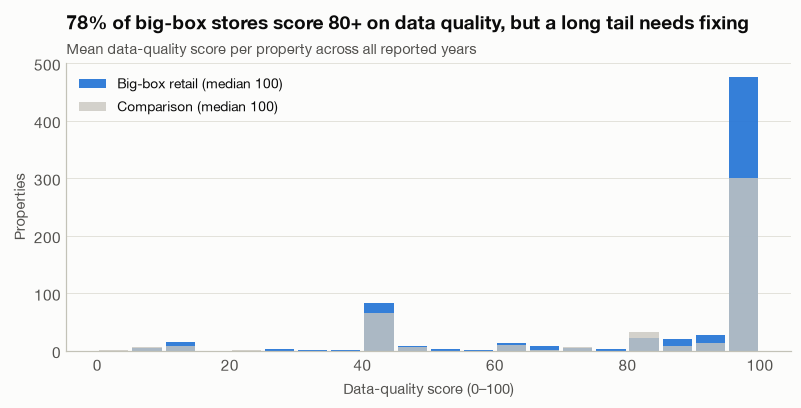

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
bins = np.arange(0, 105, 5)
for name, color in [("Big-box retail", viz.BLUE), ("Comparison", viz.CONTEXT)]:
    s = scores.loc[scores.cohort == name, "dq_score"]
    ax.hist(s, bins=bins, color=color, alpha=0.95 if name == "Big-box retail" else 0.8,
            label=f"{name} (median {s.median():.0f})", rwidth=0.88)
ax.set_xlabel("Data-quality score (0–100)")
ax.set_ylabel("Properties")
ax.legend(loc="upper left")
share_good = (scores.loc[scores.cohort == "Big-box retail", "dq_score"] >= 80).mean()
viz.title(ax, f"{share_good:.0%} of big-box stores score 80+ on data quality, but a long tail needs fixing",
          "Mean data-quality score per property across all reported years")
viz.save(fig, "01_dq_scores")
plt.show()

## 4 · Clean tables → Parquet + DuckDB
Exclusion-grade rows are dropped for benchmarking. Soft flags stay as columns so later notebooks can filter on them, for example when choosing the focus portfolio for the bill audit.

In [10]:
keep = q.clean_mask(flagged)
annual_clean = kpis.add_intensities(flagged[keep].copy())
annual_clean = annual_clean.merge(scores[["property_id", "dq_score"]], on="property_id", how="left")
weather_monthly = monthly_degree_days(weather_daily)

io.save(flagged, "annual_flagged")
io.save(annual_clean, "annual_clean")
io.save(monthly_raw, "monthly")
io.save(weather_monthly, "weather_monthly")
io.save(scores, "dq_scores")

con = io.duckdb_connect()
con.sql("""
    SELECT year, cohort, COUNT(*) AS properties,
           ROUND(MEDIAN(site_eui), 1) AS median_site_eui_kbtu_ft2,
           ROUND(MEDIAN(site_eui_kwh_m2), 0) AS median_site_eui_kwh_m2
    FROM annual_clean GROUP BY ALL ORDER BY cohort, year
""").df()

,year,cohort,properties,median_site_eui_kbtu_ft2,median_site_eui_kwh_m2
0,2019,Big-box retail,297,72.50,229.00
1,2020,Big-box retail,297,60.60,191.00
2,2021,Big-box retail,288,65.90,208.00
3,2022,Big-box retail,295,65.30,206.00
4,2023,Big-box retail,294,61.10,193.00
5,2024,Big-box retail,316,62.80,198.00
6,2019,Comparison,142,145.30,458.00
7,2020,Comparison,170,135.10,426.00
8,2021,Comparison,206,135.10,426.00
9,2022,Comparison,210,142.60,450.00


In [11]:
monthly_cov = flagged[flagged.year.isin(years_monthly)]
mismatch_ok = flagged.loc[flagged.n_valid == 12, "monthly_annual_ratio"].sub(1).abs().le(0.10).mean()
io.save_result("01_quality", {
    "annual_rows": len(annual_raw),
    "annual_years": [int(annual_raw.year.min()), int(annual_raw.year.max())],
    "monthly_rows": len(monthly_raw),
    "monthly_first": f"{monthly_raw.month.min():%Y-%m}",
    "monthly_last": f"{monthly_raw.month.max():%Y-%m}",
    "monthly_missing_years": missing_monthly_years,
    "weather_days": len(weather_daily),
    "weather_last": f"{weather_daily.date.max():%Y-%m-%d}",
    "properties": int(annual_raw.property_id.nunique()),
    "big_box_latest_year": int(bb.index[-1]),
    "big_box_latest_count": int(bb.iloc[-1]),
    "rows_kept": int(keep.sum()),
    "rows_kept_share": float(keep.mean()),
    "removed_by_rule": dict(zip(wf.step.iloc[1:], wf.rows_removed.iloc[1:].astype(int))),
    "big_box_share_score80": float(share_good),
    "monthly_matches_annual_share": float(mismatch_ok),
    "d4_present": bool(d4_present),
})

In [12]:
biggest = wf.iloc[1:].sort_values("rows_removed", ascending=False).iloc[0]
display(Markdown(f"""
## Key findings
1. **Coverage.** {annual_raw.property_id.nunique():,} retail properties across {annual_raw.year.nunique()} disclosure years ({annual_raw.year.min()}–{annual_raw.year.max()}). The big-box cohort is {bb.iloc[-1]} properties in {bb.index[-1]}. Monthly bills run {monthly_raw.month.min():%b %Y}–{monthly_raw.month.max():%b %Y}, with **{', '.join(map(str, missing_monthly_years))} not published**.
2. **Quality gate.** {keep.sum():,} of {len(flagged):,} property-year rows ({keep.mean():.0%}) pass. The largest single loss is *{biggest.step.lower()}* (−{biggest.rows_removed:,} rows).
3. **The two releases agree.** Where both exist, the monthly sum is within 10% of the annual electricity total for {mismatch_ok:.1%} of property-years, so the monthly series can be trusted as bills.
4. **Scale errors are real.** {int(flagged.dq_scale_error.sum())} rows look about 1,000× off (unit typed wrong) and would wreck any portfolio average if left in.
5. **Data integrity is a KPI in itself.** {share_good:.0%} of big-box stores score 80+. The rest are the first stores to chase for meter reads before any savings claim.
"""))


## Key findings
1. **Coverage.** 1,166 retail properties across 6 disclosure years (2019–2024). The big-box cohort is 431 properties in 2024. Monthly bills run Jan 2018–Dec 2024, with **2022 not published**.
2. **Quality gate.** 2,996 of 3,428 property-year rows (87%) pass. The largest single loss is *no energy reported* (−324 rows).
3. **The two releases agree.** Where both exist, the monthly sum is within 10% of the annual electricity total for 98.4% of property-years, so the monthly series can be trusted as bills.
4. **Scale errors are real.** 30 rows look about 1,000× off (unit typed wrong) and would wreck any portfolio average if left in.
5. **Data integrity is a KPI in itself.** 78% of big-box stores score 80+. The rest are the first stores to chase for meter reads before any savings claim.
